<a href="https://colab.research.google.com/github/suryansh24-coder/Machine-Learning-Journey/blob/main/Encoding__Numerical_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

In [4]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [5]:
df = pd.read_csv('traind.csv' , usecols=['Age','Fare','Survived'])

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Age       714 non-null    float64
 2   Fare      891 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 21.0 KB


In [7]:
df.describe()

,Survived,Age,Fare
count,891.000000,714.000000,891.000000
mean,0.383838,29.699118,32.204208
std,0.486592,14.526497,49.693429
min,0.000000,0.420000,0.000000
25%,0.000000,20.125000,7.910400
50%,0.000000,28.000000,14.454200
75%,1.000000,38.000000,31.000000
max,1.000000,80.000000,512.329200


In [8]:
df.dropna(inplace=True)

In [9]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 714 entries, 0 to 890
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  714 non-null    int64  
 1   Age       714 non-null    float64
 2   Fare      714 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 22.3 KB


In [11]:
df.shape

(714, 3)

In [12]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [13]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [14]:
X_train,X_test ,y_train,y_test = train_test_split(X,y,test_size=0.2,  random_state=42)

In [15]:
X_train.head()

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542
253,30.0,16.1000
719,33.0,7.7750
666,25.0,13.0000


In [17]:
clf = DecisionTreeClassifier()

In [19]:
clf.fit(X_train ,y_train)
y_pred = clf.predict(X_test)

In [20]:
accuracy_score(y_test , y_pred)

0.6223776223776224

In [21]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6317097026604068)

In [24]:
kbins_age = KBinsDiscretizer(n_bins = 5 , encode='ordinal' , strategy='kmeans')
kbins_fare = KBinsDiscretizer(n_bins = 5 , encode='ordinal' , strategy='kmeans')

In [25]:
trf = ColumnTransformer([
    ('first',kbins_age,[0]),
    ('second',kbins_fare,[1])
])

In [26]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

In [27]:
trf.named_transformers_['first'].n_bins_

array([5])

In [29]:
trf.named_transformers_['first'].n_bins_

array([5])

In [30]:
trf.named_transformers_['first']

KBinsDiscretizer(encode='ordinal', strategy='kmeans')

In [31]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42      , 12.69636862, 27.02765256, 39.35418895, 54.21464646,
              80.        ])                                                   ],
      dtype=object)

In [33]:
trf.named_transformers_['second'].bin_edges_

array([array([  0.        ,  42.42381445, 100.62403884, 186.50018901,
              376.60581786, 512.3292    ])                           ],
      dtype=object)

In [34]:
output = pd.DataFrame({
    "age" : X_train['Age'] ,
    "age_trf" : X_train_trf[:,0] ,
    "fare" : X_train['Fare'] ,
    "fare_trf" : X_train_trf[:, 1]
})

In [38]:
output['age_labels'] = pd.cut(x=X_train['Age'],bins=trf.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_labels'] = pd.cut(x=X_train['Fare'],bins=trf.named_transformers_['second'].bin_edges_[0].tolist())

In [39]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
463,48.0,3.0,13.0,0.0,"(39.354, 54.215]","(0.0, 42.424]"
754,48.0,3.0,65.0,1.0,"(39.354, 54.215]","(42.424, 100.624]"
15,55.0,4.0,16.0,0.0,"(54.215, 80.0]","(0.0, 42.424]"
720,6.0,0.0,33.0,0.0,"(0.42, 12.696]","(0.0, 42.424]"
200,28.0,2.0,9.5,0.0,"(27.028, 39.354]","(0.0, 42.424]"


In [40]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2 = clf.predict(X_test_trf)

In [41]:
accuracy_score(y_test,y_pred2)

0.6223776223776224

In [44]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6317292644757433)

In [48]:
def discretize(bins,strategy):
  kbins_age = KBinsDiscretizer(n_bins = bins , encode='ordinal',strategy=strategy)
  kbins_fare = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)

  trf = ColumnTransformer([
      ('first',kbins_age,[0]),
      ('second' , kbins_fare,[1])
  ])

  X_trf = trf.fit_transform(X)
  print(np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy')))

  plt.figure(figsize=(14,4))
  plt.subplot(121)
  plt.hist(X['Age'])
  plt.title("Before")

  plt.subplot(122)
  plt.hist(X_trf[:,0],color='red')
  plt.title("After")
  plt.legend()

  plt.show()

0.63589593114241


/tmp/ipykernel_3896/13821759.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


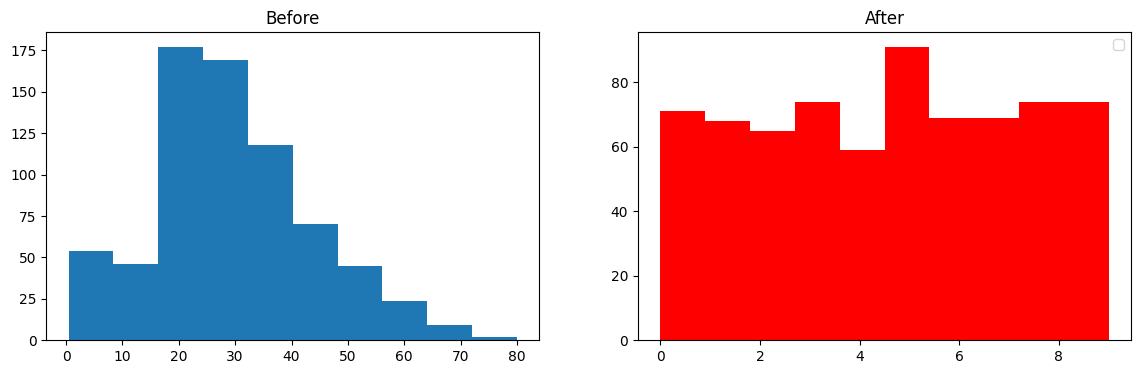

In [49]:
discretize(10,'quantile')

0.6359154929577464


/tmp/ipykernel_3896/13821759.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


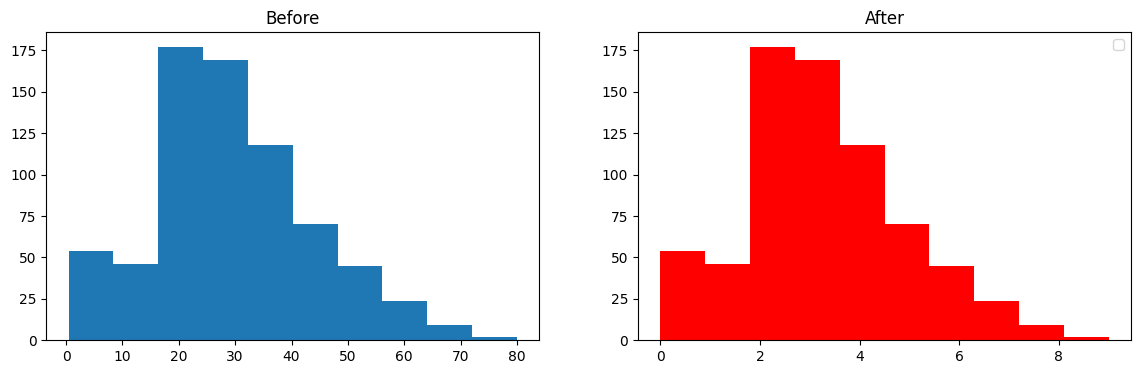

In [50]:
discretize(10,'uniform')

0.6261150234741784


/tmp/ipykernel_3896/13821759.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


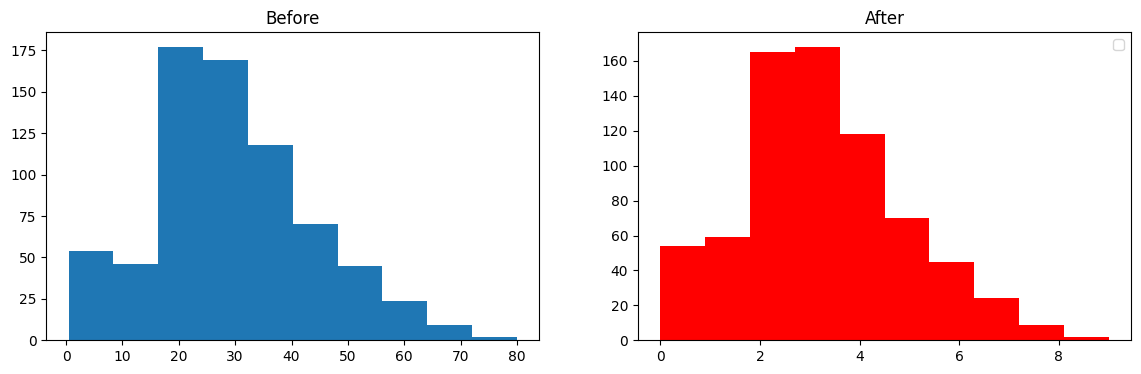

In [52]:
discretize(10,'kmeans')